# Simple fibril model parameter sweeps

## Notebook setup

### Imports

In [1]:
# Imports
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import open3d as o3d
from scipy.spatial.transform import Rotation as R
from scipy.stats import vonmises
from tqdm import tqdm
import sys
import json
from itertools import product
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from collections import defaultdict
import gc

from custom_fibril_gen_v2 import *
from nrss_fibril_functions_v2 import *

### Define Paths

In [2]:
notebookPath = pathlib.Path.cwd()
savePath = notebookPath.joinpath('simple_fibril_sweeps_outputs')
# fibrilsPath = basePath.joinpath('custom_fibril_gen', f'fixed_fibrils')

In [3]:
savePath.exists()

True

## Functions

In [4]:
def mol_orient_vectors(scenario, rotated_bb_coords, rotated_bb_axs, rotated_bb_css, rotated_fibril, set_theta):
    """
    Assigns molecular extraordinary axis vectors (unit vectors) for each fibril point based on orientation scenario.

    Orientation Scenarios:
    - A: Type II: Aligns orientation vector parallel to the fibril long axis.
    - B: Rotates from the local backbone axis by a fixed angle (set_theta).
    - C: Type I: Points radially outward from the closest backbone centerline coordinate.
    - D: Type I: Selects a random direction within the cross-sectional plane.
    - E: Type I: Psi parallel to fibril long axis psi; Theta perpendicular

    Parameters:
    - scenario: str
        Orientation scenario identifier (A, B, C, or D).
    - rotated_bb_coords: (N, 3) np.ndarray
        Backbone centerline coordinates after global rotation.
    - rotated_bb_axs: (N, 3) np.ndarray
        Local backbone long-axis unit vectors.
    - rotated_bb_css: (N, 2, 3) np.ndarray
        Short-axis cross-sectional unit vectors for each backbone point (2 per point).
    - rotated_fibril: (M, 3) np.ndarray
        Coordinates of points along the fibril for which orientations are needed.
    - set_theta: float
        Declination angle in degrees for scenario B.

    Returns:
    - fibril_vectors: (M, 3) np.ndarray
        Molecular orientation unit vectors (x, y, z) for each fibril point.
    """
    M = rotated_fibril.shape[0]  # number of fibril points
    fibril_vectors = np.zeros((M, 3))  # initialize output array
    rng = np.random.default_rng()  # random number generator for scenario D

    if scenario == 'A':
        # Orientation is aligned with local backbone long axis
        for i, fibril_point in enumerate(rotated_fibril):
            # Find nearest backbone point to fibril point
            d = np.linalg.norm(rotated_bb_coords - fibril_point, axis=1)
            idx = np.argmin(d)
            # Use its long-axis vector as orientation
            fibril_vectors[i] = rotated_bb_axs[idx]

    elif scenario == 'B':
        # Orientation is rotated from the backbone long axis by set_theta degrees
        theta_rad = np.deg2rad(set_theta)
        for i, fibril_point in enumerate(rotated_fibril):
            # Find nearest backbone point
            d = np.linalg.norm(rotated_bb_coords - fibril_point, axis=1)
            idx = np.argmin(d)
            long_axis_vec = rotated_bb_axs[idx]  # local backbone axis vector
            # Construct orthogonal vector to long_axis_vec
            ortho_vec = np.cross(long_axis_vec, [0, 0, 1])  # try using z-axis
            if np.linalg.norm(ortho_vec) < 1e-6:
                ortho_vec = np.cross(long_axis_vec, [0, 1, 0])  # fallback if nearly parallel
            ortho_vec /= np.linalg.norm(ortho_vec)
            # Combine axis and orthogonal vector using the declination angle
            orient_vec = np.cos(theta_rad) * long_axis_vec + np.sin(theta_rad) * ortho_vec
            fibril_vectors[i] = orient_vec / np.linalg.norm(orient_vec)

    elif scenario == 'C':
        # Orientation points outward from fibril toward closest backbone point
        for i, fibril_point in enumerate(rotated_fibril):
            # Compute displacements from all backbone points
            bb_displacements = rotated_bb_coords - fibril_point
            bb_distances = np.linalg.norm(bb_displacements, axis=1)
            idx = np.argmin(bb_distances)
            # Vector pointing from fibril point to backbone (reversed)
            displacement = bb_displacements[idx]
            fibril_vectors[i] = -displacement / np.linalg.norm(displacement)

    elif scenario == 'D':
        # Orientation is random within the cross-sectional plane
        for i, fibril_point in enumerate(rotated_fibril):
            # Find nearest backbone point
            dists = np.linalg.norm(rotated_bb_coords - fibril_point, axis=1)
            idx = np.argmin(dists)
            # Get two orthogonal cross-sectional directions at that point
            css1 = rotated_bb_css[0, idx]  # short-axis vector 1
            css2 = rotated_bb_css[1, idx]  # short-axis vector 2
            # Choose a random linear combination of the two (unit circle)
            alpha = rng.uniform(0, 2 * np.pi)
            orient_vec = np.cos(alpha) * css1 + np.sin(alpha) * css2
            fibril_vectors[i] = orient_vec / np.linalg.norm(orient_vec)

    elif scenario == 'E':
        # Psi is aligned with fibril long axis psi: theta perpendicular
        for i, fibril_point in enumerate(rotated_fibril):
            # Find nearest backbone point to fibril point
            d = np.linalg.norm(rotated_bb_coords - fibril_point, axis=1)
            idx = np.argmin(d)
            # Use its cross product with one of its two in-plane perpendicular vectors 

            # For now just chose y-axis... only will work for specific long axis orientation
            fibril_vectors[i] = np.cross(rotated_bb_axs[idx], [0,1,0])  
            
    else:
        raise ValueError(f"Unknown scenario '{scenario}'")

    return fibril_vectors


def style_axes(ax, background, hide_all=True):
    if hide_all:
        ax.set_axis_off()
    else:
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")
        ax.grid(False)
        ax.xaxis.pane.set_visible(False)
        ax.yaxis.pane.set_visible(False)
        ax.zaxis.pane.set_visible(False)


def set_equal_aspect_3d(ax, X, Y, Z, zoom=1.0):
    max_range = np.array([X.max() - X.min(), Y.max() - Y.min(), Z.max() - Z.min()]).max() / 2.0
    max_range *= zoom
    mid_x = (X.max() + X.min()) * 0.5
    mid_y = (Y.max() + Y.min()) * 0.5
    mid_z = (Z.max() + Z.min()) * 0.5
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)
    ax.set_box_aspect([1, 1, 1])


def orientation_sphere_legend(ax, radius=1.0, detail=60, offset=(0, 0, 0), length=100, scale=1, alpha=1.0):
    """
    Adds a colored orientation sphere to the current 3D plot.
    RGB mapping:
      - R = (x + 1) / 2
      - G = (y + 1) / 2
      - B = (z + 1) / 2
    where (x, y, z) are unit vector components on the sphere.
    """
    u = np.linspace(0, 2 * np.pi, detail)
    v = np.linspace(0, np.pi, detail)
    u, v = np.meshgrid(u, v)

    x = radius * np.cos(u) * np.sin(v)
    y = radius * np.sin(u) * np.sin(v)
    z = radius * np.cos(v)

    # Normalize and map to RGB
    R = (x / radius + 1) / 2
    G = (y / radius + 1) / 2
    B = (z / radius + 1) / 2
    colors = np.stack([R, G, B], axis=-1)

    # Plot surface with RGB mapping
    ax.plot_surface(x * scale + offset[0],
                    y * scale + offset[1],
                    z * scale + offset[2] + length * 2,
                    rstride=1, cstride=1, facecolors=colors,
                    linewidth=0.1, antialiased=False, shade=False, alpha=alpha)
    return ax


def draw_quiver_axes(ax, origin=(0, 0, 0), length=0.1):
    """
    Draws RGB-colored quiver axes based on unit vector direction.
    RGB mapping:
      - X axis = red
      - Y axis = green
      - Z axis = blue
    """
    origin = np.atleast_2d(origin)
    U = np.array([[length, 0, 0], [0, length, 0], [0, 0, length]])
    X = np.repeat(origin, 3, axis=0)

    colors = [(1, 0, 0), (0, 1, 0), (0, 0, 1)]  # RGB for x, y, z

    for i in range(3):
        # ax.quiver(X[i, 0], X[i, 1], X[i, 2],
        #           U[i, 0], U[i, 1], U[i, 2],
        #           color='grey', linewidth=3, arrow_length_ratio=0.2)
        ax.quiver(X[i, 0], X[i, 1], X[i, 2],
                  U[i, 0], U[i, 1], U[i, 2],
                  color=colors[i], linewidth=1, arrow_length_ratio=0.2)

    ax.text(origin[0, 0] + length * 1.3, origin[0, 1], origin[0, 2], 'X', color='black')
    ax.text(origin[0, 0], origin[0, 1] + length * 1.1, origin[0, 2], 'Y', color='black')
    ax.text(origin[0, 0], origin[0, 1], origin[0, 2] + length * 1.1, 'Z', color='black')


def plot_pointcloud(pcd, background="white", elev=45, azim=315, show=True, savePath=None,
                    zoom=1.0, axes_origin=(0, 0, 0), sphere_origin=(0,0,100), axes_length=1, hide_axes=True):
    points = np.asarray(pcd.points)
    colors = np.asarray(pcd.colors) if pcd.has_colors() else "k"

    fig = plt.figure(figsize=(8, 8))
    fig.set(tight_layout=True)
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=2, c=colors)
    
    # Equal aspect and axis arrows
    set_equal_aspect_3d(ax, points[:, 0], points[:, 1], points[:, 2], zoom)
    draw_quiver_axes(ax, origin=axes_origin, length=axes_length)

    # Styling
    ax.set_facecolor(background)
    fig.patch.set_facecolor(background)
    ax.view_init(elev=elev, azim=azim)
    style_axes(ax, background, hide_all=hide_axes)

    if show:
        plt.show()
    if savePath:
        fig.savefig(savePath, dpi=300)


def plot_voxelgrid(voxel_grid, background="white", elev=45, azim=315, show=True, savePath=None,
                   zoom=1.0, axes_origin=(0, 0, 0), axes_length=1, hide_axes=True):
    voxel_size = voxel_grid.voxel_size
    origin = voxel_grid.origin
    voxels = voxel_grid.get_voxels()

    indices = np.stack([v.grid_index for v in voxels])
    colors = np.stack([v.color for v in voxels])
    centers = indices * voxel_size + origin

    r = voxel_size / 2
    cube = np.array([[-r, -r, -r], [+r, -r, -r], [+r, +r, -r], [-r, +r, -r],
                     [-r, -r, +r], [+r, -r, +r], [+r, +r, +r], [-r, +r, +r]])
    faces = [[0,1,2,3], [4,5,6,7], [0,1,5,4],
             [2,3,7,6], [1,2,6,5], [4,7,3,0]]

    all_verts = []
    face_colors = []

    for center, color in zip(centers, colors):
        verts = cube + center
        all_verts.extend([verts[face] for face in faces])
        face_colors.extend([color]*6)

    fig = plt.figure(figsize=(8, 8))
    fig.set(tight_layout=True)
    ax = fig.add_subplot(111, projection='3d')
    mesh = Poly3DCollection(all_verts, facecolors=face_colors, edgecolors='k', linewidths=0.05, alpha=0.95)
    ax.add_collection3d(mesh)
    
    # Equal aspect and axis arrows
    set_equal_aspect_3d(ax, centers[:, 0], centers[:, 1], centers[:, 2], zoom)
    draw_quiver_axes(ax, origin=axes_origin, length=axes_length)

    ax.set_facecolor(background)
    fig.patch.set_facecolor(background)
    ax.view_init(elev=elev, azim=azim)
    style_axes(ax, background, hide_all=hide_axes)
    
    if show:
        plt.show()
    if savePath:
        fig.savefig(savePath, dpi=300)

        
def plot_pointcloud_with_legend(pcd, background="white", elev=45, azim=315, show=True, savePath=None,
                                zoom=1.0, axes_origin=(0, 0, 0), sphere_origin=(0,0,100), axes_length=1, hide_axes=True):
    points = np.asarray(pcd.points)
    colors = np.asarray(pcd.colors) if pcd.has_colors() else "k"

    fig = plt.figure(figsize=(8, 8))
    fig.set(tight_layout=True)
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=2, c=colors)

    # Orientation sphere at origin, in front, with alpha
    orientation_sphere_legend(ax, radius=1, detail=180, offset=sphere_origin, length=axes_length, scale=axes_length * 0.7, alpha=1)
    
    # Equal aspect and axis arrows
    set_equal_aspect_3d(ax, points[:, 0], points[:, 1], points[:, 2], zoom)
    draw_quiver_axes(ax, origin=axes_origin, length=axes_length)

    # Styling
    ax.set_facecolor(background)
    fig.patch.set_facecolor(background)
    ax.view_init(elev=elev, azim=azim)
    style_axes(ax, background, hide_all=hide_axes)

    if show:
        plt.show()
    if savePath:
        fig.savefig(savePath, dpi=300)


def plot_voxelgrid_with_legend(voxel_grid, background="white", elev=45, azim=315, show=True, savePath=None,
                               zoom=1.0, axes_origin=(0, 0, 0), sphere_origin=(0,0,100), axes_length=1, hide_axes=True):
    voxel_size = voxel_grid.voxel_size
    origin = voxel_grid.origin
    voxels = voxel_grid.get_voxels()

    indices = np.stack([v.grid_index for v in voxels])
    colors = np.stack([v.color for v in voxels])
    centers = indices * voxel_size + origin

    r = voxel_size / 2
    cube = np.array([[-r, -r, -r], [+r, -r, -r], [+r, +r, -r], [-r, +r, -r],
                     [-r, -r, +r], [+r, -r, +r], [+r, +r, +r], [-r, +r, +r]])
    faces = [[0,1,2,3], [4,5,6,7], [0,1,5,4],
             [2,3,7,6], [1,2,6,5], [4,7,3,0]]

    all_verts = []
    face_colors = []

    for center, color in zip(centers, colors):
        verts = cube + center
        all_verts.extend([verts[face] for face in faces])
        face_colors.extend([color]*6)

    fig = plt.figure(figsize=(8, 8))
    fig.set(tight_layout=True)
    ax = fig.add_subplot(111, projection='3d')
    mesh = Poly3DCollection(all_verts, facecolors=face_colors, edgecolors='k', linewidths=0.05, alpha=0.95)
    ax.add_collection3d(mesh)

    set_equal_aspect_3d(ax, centers[:, 0], centers[:, 1], centers[:, 2], zoom)
    orientation_sphere_legend(ax, radius=1, detail=180,
                              offset=sphere_origin,
                              length=axes_length,
                              scale=axes_length * 0.7,
                              alpha=1)
    draw_quiver_axes(ax, origin=axes_origin, length=axes_length)

    
    ax.set_facecolor(background)
    fig.patch.set_facecolor(background)
    ax.view_init(elev=elev, azim=azim)
    style_axes(ax, background, hide_all=hide_axes)
    

    if show:
        plt.show()
    if savePath:
        fig.savefig(savePath, dpi=300)

In [5]:
def voxelized_cylinder(diameter, length, voxel_size):
    """
    Generate a list of voxel center positions inside a cylinder.

    Cylinder is aligned along Z axis and centered at (0, 0, 0).
    
    Parameters:
        diameter (float): Cylinder diameter.
        length (float): Cylinder length along Z axis.
        voxel_size (float): Size of each voxel (assumed cubic).
    
    Returns:
        np.ndarray: (N, 3) array of voxel center positions inside the cylinder.
    """
    radius = diameter / 2
    r_vox = int(np.ceil(radius / voxel_size))
    h_vox = int(np.ceil(length / 2 / voxel_size))

    x = np.arange(-r_vox, r_vox + 1) * voxel_size
    y = np.arange(-r_vox, r_vox + 1) * voxel_size
    z = np.arange(-h_vox, h_vox + 1) * voxel_size

    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')  # shape: (Nx, Ny, Nz)
    coords = np.stack([X, Y, Z], axis=-1).reshape(-1, 3)

    # Keep only points within radius in XY
    r2 = coords[:, 0]**2 + coords[:, 1]**2
    inside = r2 <= radius**2

    return coords[inside]


def mol_orient_vectors_cylinder(scenario, fibril_coords, orient_std):
    """
    Assigns molecular extraordinary axis vectors (unit vectors) for each fibril point 
    in a cylindrical fiber, centered at (0,0,0) and with its height along the Z axis.

    Orientation Scenarios:
    - A: Type II: Aligns orientation vector parallel to the fibril long axis.
    - B: Type I: Psi perpendicular to fibril long axis psi; Theta perpendicular.
    - C: Type I: Psi parallel to fibril long axis psi; Theta perpendicular.
    - D: Type I: Points radially outward from the fibril long axis.
    - E: Type I: Points randomly and perpendicular to the fibril long axis.
    - F: Type I: Like 'C' but with normal distribution from specified deviation angle std

    Parameters:
    - scenario: str
        Orientation scenario identifier (A, B, C, or D).
    - fibril_coords: (M, 3) np.ndarray
        Coordinates of points along the fibril for which orientations are needed.
    - orient_std: float or int
        Standard deviation for orientation scenarios with distributions that call for one

    Returns:
    - fibril_vectors: (M, 3) np.ndarray
        Molecular orientation unit vectors (x, y, z) for each fibril point.
    """
    M = fibril_coords.shape[0]  # number of fibril points
    fibril_vectors = np.zeros((M, 3))  # initialize output array
    rng = np.random.default_rng()  # random number generator for scenario D

    if scenario == 'A':
        # Type II: Aligns orientation vector parallel to the fibril long axis.
        for i, fibril_point in enumerate(fibril_coords):
            fibril_vectors[i] = np.array([0,0,1])

    elif scenario == 'B':
        # Type I: Psi perpendicular to fibril long axis psi; Theta perpendicular.
        for i, fibril_point in enumerate(fibril_coords):
            fibril_vectors[i] = np.array([0,1,0]) 
            
    elif scenario == 'C':
        # Type I: Psi parallel to fibril long axis psi; Theta perpendicular.
        for i, fibril_point in enumerate(fibril_coords):
            fibril_vectors[i] = np.array([-1,0,0])    

    elif scenario == 'D':
        # Type I: Points radially outward from the fibril long axis.
        for i, fibril_point in enumerate(fibril_coords):
            displacement = [0,0,fibril_point[2]] - fibril_point
            fibril_vectors[i] = -displacement / np.linalg.norm(displacement)

    elif scenario == 'E':
        # Type I: Points randomly and perpendicular to the fibril long axis.
        for i, fibril_point in enumerate(fibril_coords):
            deviation_angle = np.deg2rad(np.random.uniform(-orient_std, orient_std))
            fibril_vectors[i] = np.cos(deviation_angle) * np.array([1,0,0]) + np.sin(deviation_angle) * np.array([0,1,0])

    elif scenario == 'F':
        # Type I: Psi parallel to fibril long axis psi; Theta perpendicular.
        # Distribution defined by std (maintaining Type I)
        for i, fibril_point in enumerate(fibril_coords):
            mu_deg = 0  # Point along +/- x axis ([1,0,0])
            kappa = 1 / np.deg2rad(orient_std)**2  # shape parameter from degrees variance 
            
            angle_rad = vonmises.rvs(kappa, loc=np.deg2rad(2 * mu_deg), size=1)[0]
            deviation_angle = (np.rad2deg(angle_rad) / 2) % 180  # wrap to [0, 180)
            
            # Reflect to [0, 360) for full circular symmetry half the time
            if np.random.rand() < 0.5:
                deviation_angle = (deviation_angle + 180) % 360

            deviation_angle = np.deg2rad(deviation_angle)
            fibril_vector = np.cos(deviation_angle) * np.array([1,0,0]) + np.sin(deviation_angle) * np.array([0,1,0])
            fibril_vectors[i] = fibril_vector
            
    else:
        raise ValueError(f"Unknown scenario '{scenario}'")

    return fibril_vectors



In [6]:
deviation_angle = np.deg2rad(np.random.normal(loc=0, scale=10))
print(np.rad2deg(deviation_angle))
fibril_vector = np.cos(deviation_angle) * np.array([-1,0,0]) + np.sin(deviation_angle) * np.array([0,1,0])
print(fibril_vector)

15.803613683268548
[-0.96220082  0.27234093  0.        ]


## Define default model arguments

In [7]:
# Dont go below 260 with current code; write_materials sets it to 340. Likely fixed with more recent NRSS examples
# energies = (np.arange(265,281,5).tolist() + np.arange(281,283,1).tolist() + 
#             np.round(np.arange(282.2,288,0.2), 1).tolist() + np.arange(290,295,1).tolist() + np.arange(295,345,5).tolist())
energies = (np.arange(265,276,5).tolist() + [278, 280] + np.arange(281,283,1).tolist() + 
            np.round(np.arange(282.2,290.2,0.2), 1).tolist() + np.arange(291,295,1).tolist() + np.arange(295,345,5).tolist())

print(energies)
print(len(energies))
print(np.unique(energies).size)

[265, 270, 275, 278, 280, 281, 282, 282.2, 282.4, 282.6, 282.8, 283.0, 283.2, 283.4, 283.6, 283.8, 284.0, 284.2, 284.4, 284.6, 284.8, 285.0, 285.2, 285.4, 285.6, 285.8, 286.0, 286.2, 286.4, 286.6, 286.8, 287.0, 287.2, 287.4, 287.6, 287.8, 288.0, 288.2, 288.4, 288.6, 288.8, 289.0, 289.2, 289.4, 289.6, 289.8, 290.0, 291, 292, 293, 294, 295, 300, 305, 310, 315, 320, 325, 330, 335, 340]
61
61


In [8]:
np.round((1/(8**3)), 5)

np.float64(0.00195)

In [9]:
np.arange(0,100,10).tolist()

[0, 10, 20, 30, 40, 50, 60, 70, 80, 90]

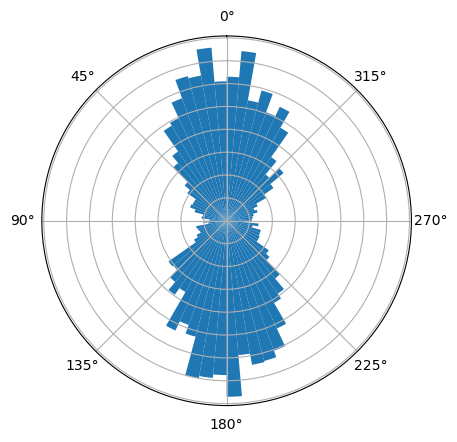

In [10]:
%matplotlib inline
plt.close('all')

# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.stats import vonmises

# Parameters
mu_deg = 0      # Preferred in-plane orientation
std_deg = 60    # Standard deviation in degrees
n_samples = 5000

# Convert std dev to kappa (von Mises concentration parameter)
kappa = 1 / np.deg2rad(std_deg)**2

# Generate samples one at a time (with 2-fold symmetry)
samples_full_deg = []
for _ in range(n_samples):
    sample_rad = vonmises.rvs(kappa, loc=np.deg2rad(2 * mu_deg), size=1)[0]
    angle_deg = (np.rad2deg(sample_rad) / 2) % 180  # wrap to [0, 180)
    
    # Reflect to [0, 360) for full circular symmetry
    if np.random.rand() < 0.5:
        samples_full_deg.append(angle_deg)
    else:
        samples_full_deg.append((angle_deg + 180) % 360)

samples_full_deg = np.array(samples_full_deg)

# === Plot circular histogram ===
n_bins = 72
bin_edges = np.linspace(0, 360, n_bins + 1)
counts, _ = np.histogram(samples_full_deg, bins=bin_edges)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
width = np.deg2rad(360 / n_bins)

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.bar(np.deg2rad(bin_centers), counts, width=width, bottom=0.0, align='center')

ax.set_theta_zero_location('N')
ax.set_theta_direction(1)
ax.set_title("")
ax.set_yticklabels('')
plt.show()


In [11]:
np.linalg.norm([500,500]) / 10

np.float64(70.71067811865476)

In [21]:
diams = np.arange(40, 70, 5).tolist() + np.arange(70, 100, 10).tolist() + np.arange(100, 200, 20).tolist() + np.arange(200,701,100).tolist()
diams

[40,
 45,
 50,
 55,
 60,
 65,
 70,
 80,
 90,
 100,
 120,
 140,
 160,
 180,
 200,
 300,
 400,
 500,
 600,
 700]

In [13]:
# diams = np.arange(20, 100, 10).tolist() + np.arange(100, 200, 20).tolist() + np.arange(200,601,100).tolist()
# diams

In [22]:
len(diams)

20

In [15]:
2000 / 128

15.625

In [16]:
((1.5625*256) / 1000) * 7.5

3.0

In [28]:
args = {}  # Arguments dictionary!

# mol_orient_list = ['D']
# frac_list = np.round(np.arange(0.1,0.04,-0.01),2).tolist()
# frac_list = [0.1,0.06,0.02]
# flex_list = np.round(np.linspace(1e-2,3e-2,10), 3).tolist()

args['params_ID'] = 86  # Generate unique identifier for these argument settings (To-Do: AutoGenerate if no matching arguments previously made)
args['sweep_params'] =        ['fibril_diam', 'fibril_tilt']  # Identify which parameter to sweep
args['sweep_params_values'] = [        diams,  [70, 80, 90]]  # Matching above selected parameters; array of values to sweep over

# Arguments for an individual fibril, all length units in Angstroms
args['fibril_length'] = 600                 # Length of fibril long axis
args['fibril_diam'] = 50                    # Diameter of fibril short axis
args['fibril_roll'] = 0                    # New parameter, set fibril roll about its long axis (rotate about Z this amount before rotating about Y)
args['fibril_tilt'] = 90                   # Tilt in degrees away from z axis (substrate normal axis)
args['core_orientation'] = 'F'         # Select orientation scenario
args['core_orientation_std'] =  75       # used in scenarios that call for normal distributions
args['core_S'] = 1                              # Orientation strength of fibril voxels (ToDo: Make S0 and add S decay / variation w.r.t. fibril geometry)
args['core_vacuum_frac'] = 0.05

# Arguments for NRSS voxel grid setup
args["voxel_size"] = 15.625  # Voxel size
args["ld"] = 256                             # XY voxels num (should be power of 2) 
args["vd"] = 128                              # Z voxels num (should be power of 2)
args['fibril_center_ld'] = int(args["ld"]/2)              # Central XY voxel position to move fibril to
args['fibril_center_vd'] = int(args["vd"]/2)               # Central Z voxel position to move fibril to

# Arguments for NRSS materials and simulating later
# args['energies'] = [265, 283, 284, 285, 286, 290, 300, 320]  # Energies at which to simulate P-RSoXS
args['matrix_vacuum_frac'] = 0.1                              # How much vacuum to mix into Material 1 (PM6) outside of fibril
args['EAngleRot'] = [0, 3, 360]

args['surface_theta'] = 60  # int or str 'afm'
args['surface_psi'] = 'random'  # 'random' or 'afm'
args['surface_size'] = 50  # depth of region to be added orientation to in Å
args['surface_S'] = 0
args['roughness_ID'] = None  # None or integer for key: 1 = PM6_CF_1 v1
args['flattening'] = 1  # Parameter from 0 (no flattening) to 1 (roughness=0, 1 voxel layer of vacuum)
args['afm_lat_scale'] = 1  # Multiplier for lateral size (1 is real size; 2 is double the size per voxel )

args['oc_ID'] = 3 # optical constants ID key: 3 = 5CBCN stitched 320
args['energies'] = energies

display(args)

{'params_ID': 86,
 'sweep_params': ['fibril_diam', 'fibril_tilt'],
 'sweep_params_values': [[40,
   45,
   50,
   55,
   60,
   65,
   70,
   80,
   90,
   100,
   120,
   140,
   160,
   180,
   200,
   300,
   400,
   500,
   600,
   700],
  [70, 80, 90]],
 'fibril_length': 600,
 'fibril_diam': 50,
 'fibril_roll': 0,
 'fibril_tilt': 90,
 'core_orientation': 'F',
 'core_orientation_std': 75,
 'core_S': 1,
 'core_vacuum_frac': 0.05,
 'voxel_size': 15.625,
 'ld': 256,
 'vd': 128,
 'fibril_center_ld': 128,
 'fibril_center_vd': 64,
 'matrix_vacuum_frac': 0.1,
 'EAngleRot': [0, 3, 360],
 'surface_theta': 60,
 'surface_psi': 'random',
 'surface_size': 50,
 'surface_S': 0,
 'roughness_ID': None,
 'flattening': 1,
 'afm_lat_scale': 1,
 'oc_ID': 3,
 'energies': [265,
  270,
  275,
  278,
  280,
  281,
  282,
  282.2,
  282.4,
  282.6,
  282.8,
  283.0,
  283.2,
  283.4,
  283.6,
  283.8,
  284.0,
  284.2,
  284.4,
  284.6,
  284.8,
  285.0,
  285.2,
  285.4,
  285.6,
  285.8,
  286.0,
  286.2,

## Build and save fibril PointClouds

In [57]:
# x = np.linspace(0,360,100)
# y = 0.5 * (1+np.cos(np.deg2rad(x)))
# plt.plot(x,y)
# plt.show()
# plt.close('all')

In [29]:
# Make list of all tuples for parameter and value to be swept over
sweep_keys = args['sweep_params']
sweep_vals = args['sweep_params_values']
combinations = list(product(*sweep_vals))

# Create folder for these argument parameters
params_ID = args['params_ID']
folder_string = f'paramsID-{params_ID}'
for sweep_key in sweep_keys:
    folder_string = folder_string + '_' + sweep_key
sweepPath = savePath.joinpath(folder_string)
sweepPath.mkdir(exist_ok=True)

# Save arguments dictionary in the above folder
json_ready_args = {
    k: v.tolist() if isinstance(v, np.ndarray) else v
    for k, v in args.items()
}
with sweepPath.joinpath('args.json').open('w') as f:
    json.dump(json_ready_args, f)

for combo in tqdm(combinations[::1], desc="Sweeping params"):
    print(combo)
    sweep_args = args.copy()
    for k, v in zip(sweep_keys, combo):
        sweep_args[k] = v

    # Create fibril unique for each combo
    
    # Make fibril
    fibril_coords = voxelized_cylinder(sweep_args['fibril_diam'], sweep_args['fibril_length'], sweep_args['voxel_size']*0.6)

    # Set molecular orientations
    fibril_vectors = mol_orient_vectors_cylinder(sweep_args['core_orientation'], fibril_coords, orient_std=sweep_args['core_orientation_std'])

    # Rotate fibril about 'y' fibril tilt
    # Rotate fibril about Z just to move psi closer away from the 0/360 weirdness along X
    rotation = R.from_euler('zyz', [sweep_args['fibril_roll'], sweep_args['fibril_tilt'], 0], degrees=True)
    rotated_fibril = rotation.apply(fibril_coords)
    rotated_fibril_vectors = rotation.apply(fibril_vectors)
    fibril_RGB_values = (rotated_fibril_vectors+1)/2
    

    # Make PointCloud
    pcd = o3d.geometry.PointCloud()
    pcd.points.extend(rotated_fibril)
    pcd.colors.extend(fibril_RGB_values)

    # Voxelize PointCloud
    vg = o3d.geometry.VoxelGrid.create_from_point_cloud(pcd, voxel_size=sweep_args["voxel_size"])

    # Save VoxelGrid and Visualizations

    label = "_".join([f"{k}-{v}" for k, v in zip(sweep_keys, combo)])

    # Save
    o3d.io.write_voxel_grid(str(sweepPath.joinpath(f'{label}.ply')), vg)
    # plot_pointcloud_with_legend(pcd, background='white', show=True, 
    #                             # axes_origin=(-160,-200,0), sphere_origin=(-160,-200,120), 
    #                             axes_origin=(-100,-140,0), sphere_origin=(-100,-140,60), 
    #                             axes_length=120, elev=25, azim=335, hide_axes=True,  
    #                             savePath=sweepPath.joinpath(f'{label}_pcd.png'))
    # plot_voxelgrid_with_legend(vg, background='white', show=True, 
    #                            # axes_origin=(-160,-200,0), sphere_origin=(-160,-200,120), 
    #                            axes_origin=(-100,-140,0), sphere_origin=(-100,-140,60), zoom=1.4, 
    #                            axes_length=120, elev=25, azim=335, hide_axes=True,  
    #                            savePath=sweepPath.joinpath(f'{label}_vg.png'))
    # View during testing
    # print('test2')
    # plot_pointcloud_with_legend(pcd, background='white', show=True, 
    #                             axes_origin=(-100,-140,0), sphere_origin=(-100,-140,60), zoom=1.4, 
    #                             axes_length=120, elev=25, azim=335, hide_axes=True)
    # plot_voxelgrid_with_legend(vg, background='white', show=True, 
    #                            axes_origin=(-100,-140,0), sphere_origin=(-100,-140,60), zoom=1.4, 
    #                            axes_length=120, elev=25, azim=335, hide_axes=True)
    
    plt.close('all')
    # gc.collect()

Sweeping params:   3%|▎         | 2/60 [00:00<00:02, 19.71it/s]

(40, 70)
(40, 80)
(40, 90)
(45, 70)


Sweeping params:  10%|█         | 6/60 [00:00<00:03, 15.36it/s]

(45, 80)
(45, 90)
(50, 70)


Sweeping params:  13%|█▎        | 8/60 [00:00<00:03, 14.62it/s]

...

Sweeping params:  97%|█████████▋| 58/60 [01:47<00:21, 10.67s/it]

(700, 80)


Sweeping params:  98%|█████████▊| 59/60 [02:02<00:11, 11.83s/it]

(700, 90)


Sweeping params: 100%|██████████| 60/60 [02:16<00:00,  2.27s/it]


In [55]:
sweepPath

PosixPath('/projects/anle1278/nrss_simple_fibril_sweeps/simple_fibril_sweeps_outputs/paramsID-75_flattening_afm_lat_scale_core_orientation_std_fibril_tilt')

In [ ]:
# Make list of all tuples for parameter and value to be swept over
sweep_keys = args['sweep_params']
sweep_vals = args['sweep_params_values']
combinations = list(product(*sweep_vals))

# Create folder for these argument parameters
params_ID = args['params_ID']
sweepPath = notebookPath.joinpath(f'{params_ID}')
sweepPath.mkdir(exist_ok=True)

# Save arguments dictionary in the above folder
json_ready_args = {
    k: v.tolist() if isinstance(v, np.ndarray) else v
    for k, v in args.items()
}
with sweepPath.joinpath('args.json').open('w') as f:
    json.dump(json_ready_args, f)

for combo in tqdm(combinations[::1], desc="Sweeping params"):
    # print(combo)
    sweep_args = args.copy()
    for k, v in zip(sweep_keys, combo):
        sweep_args[k] = v

    # Create fibril unique for each combo
    backbone_coords, backbone_axs, backbone_css, fibril_coords, fibril_shell_coords = gen_scat_coords_flexcyl(
        sweep_args['fibril_density'],
        sweep_args['fibril_length'],
        sweep_args['fibril_diam'],
        sweep_args['fibril_flex'],
        sweep_args['fibril_shell_density'],
        sweep_args['fibril_shell_length']
    )

    # Save fibril npy components:
    label = "_".join([f"{k}-{v}" for k, v in zip(sweep_keys, combo)])
    # print(label)
    
    fibrilPath = sweepPath.joinpath(f'{label}')
    fibrilPath.mkdir(exist_ok=True)
    
    np.save(fibrilPath.joinpath(f'backbone_coords.npy'), backbone_coords)
    np.save(fibrilPath.joinpath(f'backbone_axs.npy'), backbone_axs)
    np.save(fibrilPath.joinpath(f'backbone_css.npy'), backbone_css)
    np.save(fibrilPath.joinpath(f'fibril_coords.npy'), fibril_coords)
    np.save(fibrilPath.joinpath(f'fibril_shell_coords.npy'), fibril_shell_coords)

Sweeping params:  74%|███████▎  | 735/1000 [35:30<23:38,  5.35s/it]

In [50]:
whos

Variable                      Type             Data/Info
--------------------------------------------------------
Axes3D                        type             <class 'mpl_toolkits.mplot3d.axes3d.Axes3D'>
KDTree                        type             <class 'scipy.spatial._kdtree.KDTree'>
Poly3DCollection              type             <class 'mpl_toolkits.mplo<...>.art3d.Poly3DCollection'>
R                             type             <class 'scipy.spatial.tra<...>form._rotation.Rotation'>
args                          dict             n=25
backbone_axs                  ndarray          1000x3: 3000 elems, type `float64`, 24000 bytes
backbone_coords               list             n=1000
backbone_css                  ndarray          1000x2x3: 6000 elems, type `float64`, 48000 bytes
combinations                  list             n=1000
combo                         tuple            n=2
contour_length                function         <function contour_length at 0x15449394f7f0>
contour_

In [ ]:
# pcd = o3d.geometry.PointCloud()
# pcd.points.extend(np.array([[0,0,0], [100,100,100]]))
# pcd.colors.extend(np.array([[1,1,1], [1,1,1]]))

# for elev in tqdm([-60,-45,0,45,60]):
#     for azim in [0,45,90,135,180,225,270,315]:
#         print(elev,azim)
#         plot_pointcloud_with_legend(pcd, background='white', show=True, zoom=1, 
#                                     axes_origin=(0, 0, 0), 
#                                     sphere_origin=(40,40,50), 
#                                     axes_length=35, 
#                                     savePath=sphere_legends_path.joinpath(f'elev{elev}_azim{azim}.png'),
#                                     elev=elev, azim=azim, hide_axes=True)

In [ ]:
plot

## Arrange fibrils

In [ ]:
rotated_fibril.shape

In [ ]:
points = np.array([[1,1,1],
                   [2,2,2]])
colors = np.array([[1,1,1,1],
                   [2,2,2,2]])

In [ ]:
pcd = o3d.geometry.PointCloud()
pcd.points.extend(points)
pcd.colors.extend(colors)

In [ ]:
pcd.normals

In [ ]:
np.asarray(pcd.colors)

In [ ]:
pcd

In [ ]:
o3d.visualization.EV.set(pc)

## Use open3D to voxelize point cloud

In [ ]:
voxel_grid = o3d.geometry.VoxelGrid.create_from_point_cloud(pc, voxel_size=10)
voxel_grid

In [ ]:
# Convert voxel grid to list of voxels, with grid index & color

voxels = vg.get_voxels()  # returns list of voxels
indices = np.stack(list(vx.grid_index for vx in voxels))
colors = np.stack(list(vx.color for vx in voxels))

voxels

In [ ]:
indices.max()

In [ ]:
# visualize, will need to restart kernel after :O
o3d.visualization.draw_geometries([vg])

## Save open3d voxelgrids